In [1]:
import numpy as np
import scipy.stats
from matplotlib import pyplot as plt
import astropy.visualization.hist
from sklearn.neighbors import KernelDensity

In [2]:
#f function in the definition of the BH irreducible mass 
# M_irr = M * f(X)
def func(X):
    return np.sqrt((1+np.sqrt(1-X*X))/2)

Text(0.5, 1.0, '$M_{irr}$')

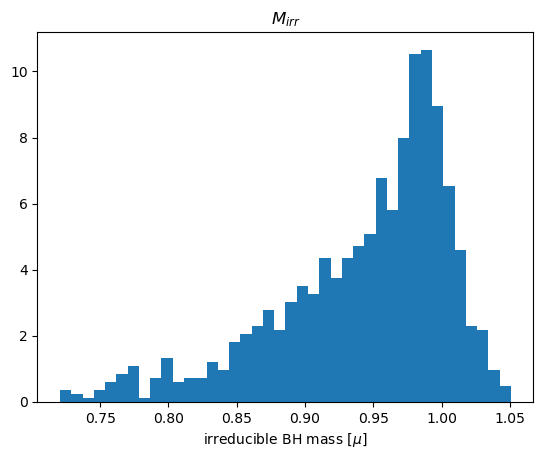

In [3]:
n = 1000 #number of data points

mu = 1 #parameters for the M distribution
sigma = 0.02

X = scipy.stats.uniform(0, 1).rvs(n)
f = func(X)
M = scipy.stats.norm(mu, sigma).rvs(n)

M_irr = f*M #simulated data set

plt.hist(M_irr, 40, density=True)
plt.xlabel('irreducible BH mass [$\mu$]')
plt.title('$M_{irr}$')
#print(len(M_irr))



(array([ 0.31105962,  0.18663577,  0.80875502,  0.62211924,  0.93317887,
         0.68433117,  0.80875502,  1.30645041,  2.11520543,  2.5506889 ,
         2.7995366 ,  3.48386777,  4.10598701,  4.54147048,  6.03455667,
         7.6520667 , 10.26496753,  7.77649055,  3.29723199,  1.61751003,
         0.31105962]),
 array([0.72056936, 0.73664345, 0.75271754, 0.76879162, 0.78486571,
        0.8009398 , 0.81701389, 0.83308798, 0.84916207, 0.86523616,
        0.88131025, 0.89738434, 0.91345842, 0.92953251, 0.9456066 ,
        0.96168069, 0.97775478, 0.99382887, 1.00990296, 1.02597705,
        1.04205113, 1.05812522]),
 [<matplotlib.patches.Polygon at 0x721e2e3bba90>])

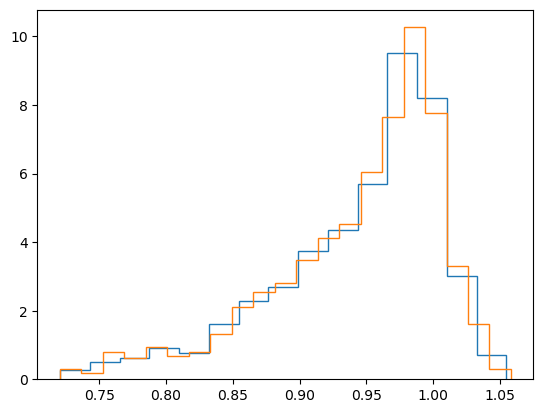

In [4]:
#plotting the data with bin sizesaccoridng to both the Scott and Freedman-Diaconis rules
astropy.visualization.hist(M_irr, bins='scott', density=True, histtype='step')
astropy.visualization.hist(M_irr, bins='freedman', density=True, histtype='step')

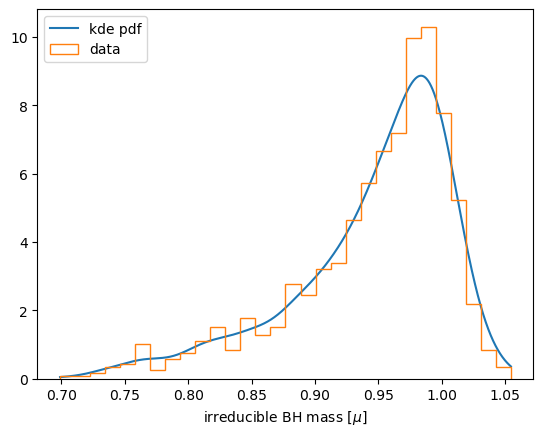

In [116]:
#we now try to fit the data with kernel density estimation

kde = KernelDensity(bandwidth=0.015, kernel='gaussian')
kde.fit(M_irr[:, np.newaxis])

x_grid = np.linspace(np.min(M_irr), np.max(M_irr), 10000)
log_pdf = kde.score_samples(x_grid[:, np.newaxis])
kde_pdf = np.exp(log_pdf)

plt.plot(x_grid, kde_pdf, label='kde pdf')
plt.hist(M_irr, 30, histtype='step', density=True, label='data')
plt.xlabel('irreducible BH mass [$\mu$]')
plt.legend()

# Distribution comparison

We use KS tests to compare the $M_{irr}$ distribution to the f and M ones. For various values of $\sigma$

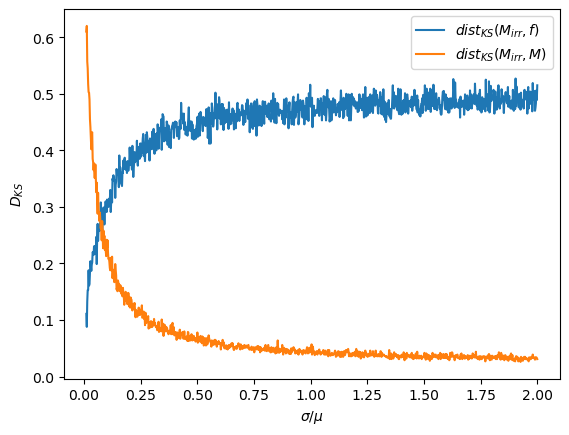

In [ ]:

sigmas = np.linspace(0.01, 2., 1000) # checked sigma values

#array to store the test scores
ks_Mirr_f = []
ks_Mirr_M = []

for sigma_i in sigmas:
    X = scipy.stats.uniform(0, 1).rvs(n)
    f = func(X)
    M = scipy.stats.norm(mu, sigma_i).rvs(n)
    
    M_irr = f*M
    ks_Mirr_f.append(scipy.stats.ks_2samp(M_irr, f).statistic)
    ks_Mirr_M.append(scipy.stats.ks_2samp(M_irr, M).statistic)
    
plt.plot(sigmas, ks_Mirr_f, label='$dist_{KS}(M_{irr}, f)$')
plt.plot(sigmas, ks_Mirr_M, label='$dist_{KS}(M_{irr}, M)$')
plt.xlabel('$\sigma/\mu$')
plt.ylabel('$D_{KS}$')
plt.legend()



We see that in the limit $\sigma << \mu$ the distribution of $M_{irr}$ tends to the distribution of $f$. 
On the other hand, in the $\sigma >> \mu$ limit, the distribution goes as the of the the physical mass of the black hole

# Comparison to analytical distributions

In [137]:
#for the f(X) and M_irr variables, the distributions are known analytically or semi-analytically,
#we compare them to the results obtained from kernel density estimation on our sample

def f_pdf_analytic (f):
    
    return 2*(2*f*f - 1)/np.sqrt(1-f*f)

def MC_f(f, M_irr, mu, sigma):
    
    return np.exp(-np.pow(M_irr/f - mu, 2)/(2*sigma*sigma))*((2*f*f -1)/(f*np.sqrt(1-f*f)))

def M_irr_pdf_analytic (M_irr, mu, sigma, n=100000):
    #the pdf is an integral function of M_irr, we evaluate it with the Monte Carlo technique
    prefactor = (np.sqrt(2/np.pi)/sigma)*(1-1/np.sqrt(2))
    f_vals = scipy.stats.uniform(1/np.sqrt(2), 1-1/np.sqrt(2)).rvs(n) #sampling from an uniform ditribution on the integration range
    
    MC_f_i = []
    for f in f_vals:
        MC_f_i.append(MC_f(f, M_irr, mu, sigma))
    
    I = prefactor*(1/n)*np.sum(MC_f_i)
    return I


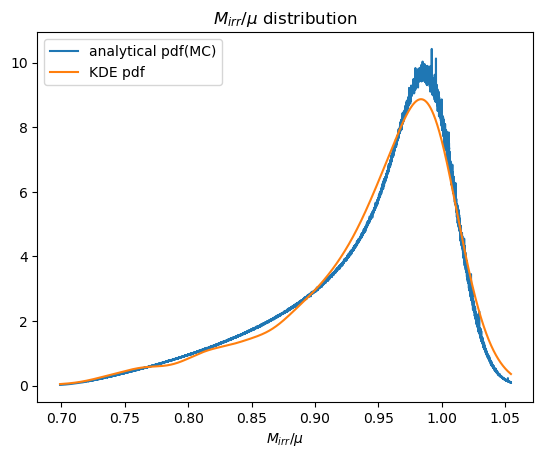

In [138]:
#comparison for the M_irr distribution
M_irr_pdf_an = []

for x_i in x_grid:
    M_irr_pdf_an.append(M_irr_pdf_analytic(x_i, mu, sigma))

#plotting the comparison
plt.plot(x_grid, M_irr_pdf_an, label='analytical pdf(MC)')
plt.plot(x_grid, kde_pdf, label='KDE pdf')
plt.title('$M_{irr}/\mu$ distribution')
plt.xlabel('$M_{irr}/\mu$')
plt.legend()


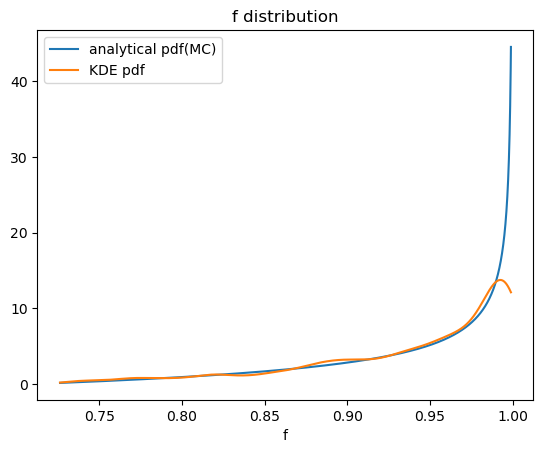

In [ ]:
f_grid = np.linspace(np.min(f), np.max(f)-0.001, 10000)
f_pdf_an = []
for f_i in f_grid:
    f_pdf_an.append(f_pdf_analytic(f_i))

#KDE for the the f sample
kde_f = KernelDensity(bandwidth=0.01, kernel='gaussian')
kde_f.fit(f[:, np.newaxis])
log_pdf_f = kde_f.score_samples(f_grid[:, np.newaxis])
kde_pdf_f = np.exp(log_pdf_f)

#plot
plt.plot(f_grid, f_pdf_an, label='analytical pdf')
plt.plot(f_grid, kde_pdf_f, label='KDE pdf')
plt.title('f distribution')
plt.xlabel('f')
plt.legend()
